## Machine learning

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

In [2]:
data = pd.read_csv('../data/loan_data.csv')
data.head(5)

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,,1.0,High School,,146114.0,815.0,18403.0,12.0,Urban,Yes,,2025-11-24,2025-10-02,,,1404.0,
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.0,,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,,Branch
3,L1003,63.0,Female,Divorced,,Graduate,Salaried,132296.0,348.0,15966.0,,Rural,,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,,38621.0,60.0,Rural,No,,2025-05-06,,10.53,39.0,13763.0,Phone


In [3]:
print(data.shape)
print(data.shape[0])  # number of rows
print(data.shape[1])  # number of columns

(50, 20)
50
20


In [4]:
print(data.isnull().sum())
print(data.isnull().sum().sum())
print((data.isnull().sum().sum()/(data.shape[0]*data.shape[1]))*100)

Loan_ID                  0
 Customer_Age            0
 Gender                  0
 Marital_Status          0
 Dependents              0
 Education_Level         0
 Employment_Type         0
 Annual_Income           0
 Credit_Score            0
 Loan_Amount             0
 Loan_Term_Months        0
 Property_Area           0
 Existing_Loan           0
 Loan_Approval_Status    0
 Application_Date        0
 Last_Payment_Date       0
 Interest_Rate           0
 Number_of_Payments      0
 Account_Balance         0
 Contact_Method          1
dtype: int64
1
0.1


In [5]:
(data.isnull().sum()/data.shape[0])*100

Loan_ID                  0.0
 Customer_Age            0.0
 Gender                  0.0
 Marital_Status          0.0
 Dependents              0.0
 Education_Level         0.0
 Employment_Type         0.0
 Annual_Income           0.0
 Credit_Score            0.0
 Loan_Amount             0.0
 Loan_Term_Months        0.0
 Property_Area           0.0
 Existing_Loan           0.0
 Loan_Approval_Status    0.0
 Application_Date        0.0
 Last_Payment_Date       0.0
 Interest_Rate           0.0
 Number_of_Payments      0.0
 Account_Balance         0.0
 Contact_Method          2.0
dtype: float64

In [6]:
print(data.notnull().sum())
print(data.notnull().sum().sum())
print((data.notnull().sum().sum()/(data.shape[0]*data.shape[1]))*100)

Loan_ID                  50
 Customer_Age            50
 Gender                  50
 Marital_Status          50
 Dependents              50
 Education_Level         50
 Employment_Type         50
 Annual_Income           50
 Credit_Score            50
 Loan_Amount             50
 Loan_Term_Months        50
 Property_Area           50
 Existing_Loan           50
 Loan_Approval_Status    50
 Application_Date        50
 Last_Payment_Date       50
 Interest_Rate           50
 Number_of_Payments      50
 Account_Balance         50
 Contact_Method          49
dtype: int64
999
99.9


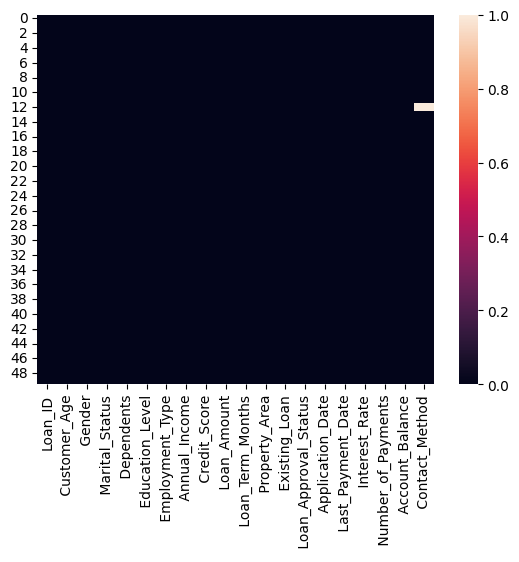

In [7]:
sns.heatmap(data.isnull())
plt.show()

## Deleting removing free and blank missing values from the dataset

In [8]:
data.head(4)

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,,1.0,High School,,146114.0,815.0,18403.0,12.0,Urban,Yes,,2025-11-24,2025-10-02,,,1404.0,
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.0,,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,,Branch
3,L1003,63.0,Female,Divorced,,Graduate,Salaried,132296.0,348.0,15966.0,,Rural,,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch


In [9]:
data.shape

(50, 20)

In [10]:
data.isnull().sum()

Loan_ID                  0
 Customer_Age            0
 Gender                  0
 Marital_Status          0
 Dependents              0
 Education_Level         0
 Employment_Type         0
 Annual_Income           0
 Credit_Score            0
 Loan_Amount             0
 Loan_Term_Months        0
 Property_Area           0
 Existing_Loan           0
 Loan_Approval_Status    0
 Application_Date        0
 Last_Payment_Date       0
 Interest_Rate           0
 Number_of_Payments      0
 Account_Balance         0
 Contact_Method          1
dtype: int64

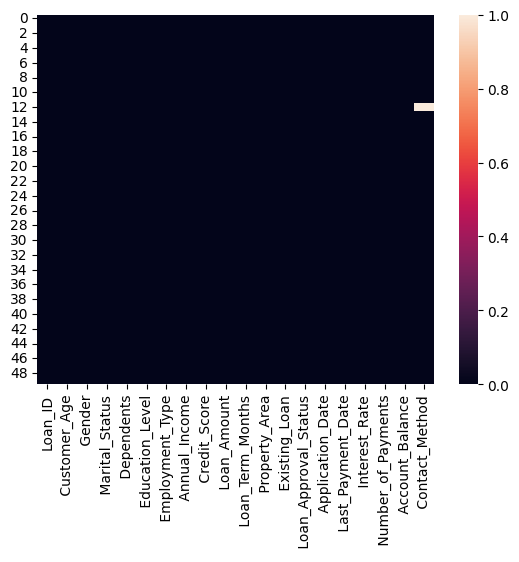

In [11]:
sns.heatmap(data.isnull())
plt.show()

In [12]:
# 1️⃣ Column names se extra spaces remove karo
data.columns = data.columns.str.strip()

# 2️⃣ Ab safe drop karo
# data.drop(columns=["Credit_Score"], inplace=True)

# 3️⃣ Check karlo
print(data.columns.tolist())



['Loan_ID', 'Customer_Age', 'Gender', 'Marital_Status', 'Dependents', 'Education_Level', 'Employment_Type', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Property_Area', 'Existing_Loan', 'Loan_Approval_Status', 'Application_Date', 'Last_Payment_Date', 'Interest_Rate', 'Number_of_Payments', 'Account_Balance', 'Contact_Method']


In [13]:
# data.replace(r'^\s*$', pd.NA, regex=True, inplace=True)
print(data.isnull().sum())


Loan_ID                 0
Customer_Age            0
Gender                  0
Marital_Status          0
Dependents              0
Education_Level         0
Employment_Type         0
Annual_Income           0
Credit_Score            0
Loan_Amount             0
Loan_Term_Months        0
Property_Area           0
Existing_Loan           0
Loan_Approval_Status    0
Application_Date        0
Last_Payment_Date       0
Interest_Rate           0
Number_of_Payments      0
Account_Balance         0
Contact_Method          1
dtype: int64


In [14]:
data.shape


(50, 20)

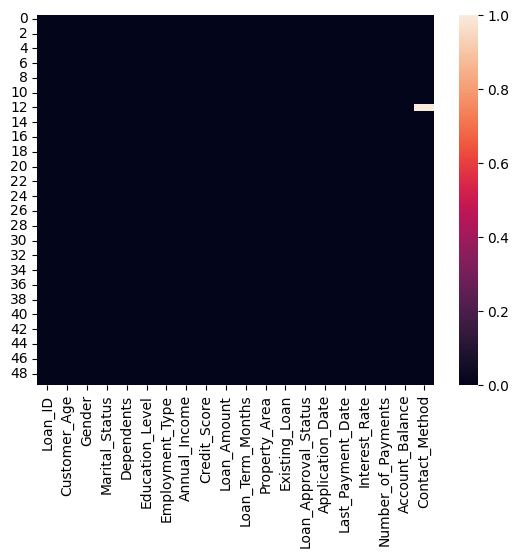

In [15]:
sns.heatmap(data.isnull())
plt.show()

In [16]:
# data.dropna(inplace=True)

In [17]:
data.shape

(50, 20)

In [18]:
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,,1.0,High School,,146114.0,815.0,18403.0,12.0,Urban,Yes,,2025-11-24,2025-10-02,,,1404.0,
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.0,,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,,Branch
3,L1003,63.0,Female,Divorced,,Graduate,Salaried,132296.0,348.0,15966.0,,Rural,,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,,38621.0,60.0,Rural,No,,2025-05-06,,10.53,39.0,13763.0,Phone


## Handaling missing values complete ho gaya. Ab aage badhte hain.

In [19]:
data.isnull().sum()

Loan_ID                 0
Customer_Age            0
Gender                  0
Marital_Status          0
Dependents              0
Education_Level         0
Employment_Type         0
Annual_Income           0
Credit_Score            0
Loan_Amount             0
Loan_Term_Months        0
Property_Area           0
Existing_Loan           0
Loan_Approval_Status    0
Application_Date        0
Last_Payment_Date       0
Interest_Rate           0
Number_of_Payments      0
Account_Balance         0
Contact_Method          1
dtype: int64

In [20]:
# data.fillna(10).head(10)


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               50 non-null     object 
 1   Customer_Age          50 non-null     object 
 2   Gender                50 non-null     object 
 3   Marital_Status        50 non-null     object 
 4   Dependents            50 non-null     object 
 5   Education_Level       50 non-null     object 
 6   Employment_Type       50 non-null     object 
 7   Annual_Income         50 non-null     float64
 8   Credit_Score          50 non-null     object 
 9   Loan_Amount           50 non-null     object 
 10  Loan_Term_Months      50 non-null     object 
 11  Property_Area         50 non-null     object 
 12  Existing_Loan         50 non-null     object 
 13  Loan_Approval_Status  50 non-null     object 
 14  Application_Date      50 non-null     object 
 15  Last_Payment_Date     50 

In [22]:
data.fillna(method='bfill', axis=1)

C:\Users\HP\AppData\Local\Temp\ipykernel_17992\3719721641.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', axis=1)


,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,,1.0,High School,,146114.0,815.0,18403.0,12.0,Urban,Yes,,2025-11-24,2025-10-02,,,1404.0,
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.0,,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,,Branch
3,L1003,63.0,Female,Divorced,,Graduate,Salaried,132296.0,348.0,15966.0,,Rural,,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,,38621.0,60.0,Rural,No,,2025-05-06,,10.53,39.0,13763.0,Phone
5,L1005,41.0,Female,Single,0.0,Postgraduate,Unemployed,500.0,316.0,33312.0,12.0,Urban,No,Rejected,,2025-05-31,7.51,39.0,19384.0,Phone
6,L1006,59.0,Male,,,Graduate,Self-employed,9999999.0,471.0,27677.0,60.0,Rural,Yes,Approved,2025-03-13,2025-11-18,,48.0,33606.0,Phone
7,L1007,39.0,Male,Divorced,4.0,Postgraduate,Salaried,43328.0,519.0,36289.0,60.0,Urban,No,Approved,2025-02-22,2025-11-13,10.72,,10860.0,
8,L1008,43.0,Female,Single,3.0,,,13910081.0,457.0,,60.0,,Yes,Approved,2025-12-13,2025-07-05,8.97,47.0,39757.0,Phone
9,L1009,31.0,Male,Single,4.0,High School,Salaried,111412.0,,47675.0,36.0,Semiurban,Yes,Approved,2025-10-07,2025-10-23,7.89,38.0,16106.0,


In [23]:
data["Gender"].mode()[0]
data["Gender"].fillna(data["Gender"].mode()[0],inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_17992\2413550165.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Gender"].fillna(data["Gender"].mode()[0],inplace=True)


In [24]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               50 non-null     object 
 1   Customer_Age          50 non-null     object 
 2   Gender                50 non-null     object 
 3   Marital_Status        50 non-null     object 
 4   Dependents            50 non-null     object 
 5   Education_Level       50 non-null     object 
 6   Employment_Type       50 non-null     object 
 7   Annual_Income         50 non-null     float64
 8   Credit_Score          50 non-null     object 
 9   Loan_Amount           50 non-null     object 
 10  Loan_Term_Months      50 non-null     object 
 11  Property_Area         50 non-null     object 
 12  Existing_Loan         50 non-null     object 
 13  Loan_Approval_Status  50 non-null     object 
 14  Application_Date      50 non-null     object 
 15  Last_Payment_Date     50 

In [25]:
data.select_dtypes(include=['object']).isnull().sum()

Loan_ID                 0
Customer_Age            0
Gender                  0
Marital_Status          0
Dependents              0
Education_Level         0
Employment_Type         0
Credit_Score            0
Loan_Amount             0
Loan_Term_Months        0
Property_Area           0
Existing_Loan           0
Loan_Approval_Status    0
Application_Date        0
Last_Payment_Date       0
Interest_Rate           0
Number_of_Payments      0
Account_Balance         0
Contact_Method          1
dtype: int64

In [26]:
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].fillna(data[col].mode()[0])


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               50 non-null     object 
 1   Customer_Age          50 non-null     object 
 2   Gender                50 non-null     object 
 3   Marital_Status        50 non-null     object 
 4   Dependents            50 non-null     object 
 5   Education_Level       50 non-null     object 
 6   Employment_Type       50 non-null     object 
 7   Annual_Income         50 non-null     float64
 8   Credit_Score          50 non-null     object 
 9   Loan_Amount           50 non-null     object 
 10  Loan_Term_Months      50 non-null     object 
 11  Property_Area         50 non-null     object 
 12  Existing_Loan         50 non-null     object 
 13  Loan_Approval_Status  50 non-null     object 
 14  Application_Date      50 non-null     object 
 15  Last_Payment_Date     50 

In [28]:
data.isnull().sum()

Loan_ID                 0
Customer_Age            0
Gender                  0
Marital_Status          0
Dependents              0
Education_Level         0
Employment_Type         0
Annual_Income           0
Credit_Score            0
Loan_Amount             0
Loan_Term_Months        0
Property_Area           0
Existing_Loan           0
Loan_Approval_Status    0
Application_Date        0
Last_Payment_Date       0
Interest_Rate           0
Number_of_Payments      0
Account_Balance         0
Contact_Method          0
dtype: int64

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               50 non-null     object 
 1   Customer_Age          50 non-null     object 
 2   Gender                50 non-null     object 
 3   Marital_Status        50 non-null     object 
 4   Dependents            50 non-null     object 
 5   Education_Level       50 non-null     object 
 6   Employment_Type       50 non-null     object 
 7   Annual_Income         50 non-null     float64
 8   Credit_Score          50 non-null     object 
 9   Loan_Amount           50 non-null     object 
 10  Loan_Term_Months      50 non-null     object 
 11  Property_Area         50 non-null     object 
 12  Existing_Loan         50 non-null     object 
 13  Loan_Approval_Status  50 non-null     object 
 14  Application_Date      50 non-null     object 
 15  Last_Payment_Date     50 

In [30]:
data.select_dtypes(include=['float64']).columns

Index(['Annual_Income'], dtype='object')

In [31]:
si = SimpleImputer(strategy="mean")
ar = si.fit_transform(data[['Customer_Age', 'Dependents', 'Annual_Income', 'Credit_Score',
       'Loan_Amount', 'Loan_Term_Months', 'Interest_Rate',
       'Number_of_Payments', 'Account_Balance']])

ValueError: Cannot use mean strategy with non-numeric data:
could not convert string to float: '             '

In [ ]:
new_data = pd.DataFrame(ar,columns=data.select_dtypes(include=['float64']).columns)

In [ ]:
new_data.isnull().sum()

Customer_Age          0
Dependents            0
Annual_Income         0
Credit_Score          0
Loan_Amount           0
Loan_Term_Months      0
Interest_Rate         0
Number_of_Payments    0
Account_Balance       0
dtype: int64

In [ ]:
new_data

,Customer_Age,Dependents,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,Number_of_Payments,Account_Balance
0,59.000000,1.000000,146114.000000,815.000000,18403.000000,12.000000,8.946977,36.302326,1404.000000
1,49.000000,1.000000,81135.000000,846.000000,37097.000000,24.000000,11.000000,36.302326,41943.000000
2,35.000000,3.000000,70108.000000,491.000000,18121.000000,12.000000,12.080000,37.000000,25792.511628
3,63.000000,2.162791,132296.000000,348.000000,15966.000000,37.395349,12.390000,19.000000,30189.000000
4,28.000000,2.000000,114179.000000,558.930233,38621.000000,60.000000,10.530000,39.000000,13763.000000
5,41.000000,0.000000,86066.744186,316.000000,33312.000000,12.000000,7.510000,39.000000,19384.000000
6,59.000000,2.162791,86066.744186,471.000000,27677.000000,60.000000,8.946977,48.000000,33606.000000
7,39.000000,4.000000,43328.000000,519.000000,36289.000000,60.000000,10.720000,36.302326,10860.000000
8,43.000000,3.000000,139181.000000,457.000000,26208.209302,60.000000,8.970000,47.000000,39757.000000
9,31.000000,4.000000,111412.000000,558.930233,47675.000000,36.000000,7.890000,38.000000,16106.000000


In [ ]:
data["Loan_Amount"].mean()

np.float64(26208.20930232558)

In [ ]:
new_data

,Customer_Age,Dependents,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,Number_of_Payments,Account_Balance
0,59.000000,1.000000,146114.000000,815.000000,18403.000000,12.000000,8.946977,36.302326,1404.000000
1,49.000000,1.000000,81135.000000,846.000000,37097.000000,24.000000,11.000000,36.302326,41943.000000
2,35.000000,3.000000,70108.000000,491.000000,18121.000000,12.000000,12.080000,37.000000,25792.511628
3,63.000000,2.162791,132296.000000,348.000000,15966.000000,37.395349,12.390000,19.000000,30189.000000
4,28.000000,2.000000,114179.000000,558.930233,38621.000000,60.000000,10.530000,39.000000,13763.000000
5,41.000000,0.000000,86066.744186,316.000000,33312.000000,12.000000,7.510000,39.000000,19384.000000
6,59.000000,2.162791,86066.744186,471.000000,27677.000000,60.000000,8.946977,48.000000,33606.000000
7,39.000000,4.000000,43328.000000,519.000000,36289.000000,60.000000,10.720000,36.302326,10860.000000
8,43.000000,3.000000,139181.000000,457.000000,26208.209302,60.000000,8.970000,47.000000,39757.000000
9,31.000000,4.000000,111412.000000,558.930233,47675.000000,36.000000,7.890000,38.000000,16106.000000


In [ ]:
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,Divorced,1.0,High School,Self-employed,146114.0,815.0,18403.0,12.0,Urban,Yes,Approved,2025-11-24,2025-10-02,NaN,NaN,1404.0,Branch
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,Self-employed,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch
3,L1003,63.0,Female,Divorced,NaN,Graduate,Salaried,132296.0,348.0,15966.0,NaN,Rural,Yes,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,NaN,38621.0,60.0,Rural,No,Approved,2025-05-06,2025-02-10,10.53,39.0,13763.0,Phone


In [ ]:
data.isnull().sum()

Loan_ID                 0
Customer_Age            7
Gender                  0
Marital_Status          0
Dependents              7
Education_Level         0
Employment_Type         0
Annual_Income           7
Credit_Score            7
Loan_Amount             7
Loan_Term_Months        7
Property_Area           0
Existing_Loan           0
Loan_Approval_Status    0
Application_Date        0
Last_Payment_Date       0
Interest_Rate           7
Number_of_Payments      7
Account_Balance         7
Contact_Method          0
dtype: int64

In [ ]:
data["Gender"].fillna(data["Gender"].mode()[0],inplace=True)
data["Marital_Status"].fillna(data["Marital_Status"].mode()[0],inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_20144\1278339984.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Gender"].fillna(data["Gender"].mode()[0],inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_20144\1278339984.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [ ]:
en_data = data[["Gender","Marital_Status"]]
en_data

,Gender,Marital_Status
0,Male,Divorced
1,Female,Single
2,Male,Single
3,Female,Divorced
4,Male,Single
5,Female,Single
6,Male,Divorced
7,Male,Divorced
8,Female,Single
9,Male,Single


In [ ]:
pd.get_dummies(en_data)


,Gender_Female,Gender_Male,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single
0,False,True,True,False,False
1,True,False,False,False,True
2,False,True,False,False,True
3,True,False,True,False,False
4,False,True,False,False,True
5,True,False,False,False,True
6,False,True,True,False,False
7,False,True,True,False,False
8,True,False,False,False,True
9,False,True,False,False,True


In [ ]:
ohe = OneHotEncoder(drop="first")
ar = ohe.fit_transform(en_data).toarray()
ar

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 1.],
       [0., 0., 0.],
       [1., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 1.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 1.],
       [0., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 0.],
       [1., 1., 0.],
       [1., 0., 0.],
       [0., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [1., 0., 1.],
       [0., 0., 1.],
       [1., 1., 0.],
       [0., 0., 0.],
       [1., 0., 0.],
       [1., 1., 0.],
       [0., 0

In [ ]:
pd.DataFrame(ar,columns=["Gender_Male","Marital_Status_Married","Marital_Status_Single"])

,Gender_Male,Marital_Status_Married,Marital_Status_Single
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,1.0
3,0.0,0.0,0.0
4,1.0,0.0,1.0
5,0.0,0.0,1.0
6,1.0,0.0,0.0
7,1.0,0.0,0.0
8,0.0,0.0,1.0
9,1.0,0.0,1.0


In [ ]:
df = pd.DataFrame({"name":["wscube","cow","dog","cat","black","chair"]})
df

,name
0,wscube
1,cow
2,dog
3,cat
4,black
5,chair


In [ ]:
le = LabelEncoder()
df["en_name"]= le.fit_transform(df[["name"]])

c:\Users\HP\Desktop\Projects\Machine Learning\venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
df

,name,en_name
0,wscube,5
1,cow,3
2,dog,4
3,cat,1
4,black,0
5,chair,2


In [ ]:
data.head()
print(data["Property_Area"].unique())

['Urban' 'Rural' 'Semiurban']


In [ ]:
la = LabelEncoder()
la.fit(data["Property_Area"])


LabelEncoder()

In [ ]:
data["Property_Area"]=la.transform(data["Property_Area"])
data

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,Divorced,1.0,High School,Self-employed,146114.0,815.0,18403.0,12.0,2,Yes,Approved,2025-11-24,2025-10-02,NaN,NaN,1404.0,Branch
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,2,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,Self-employed,70108.0,491.0,18121.0,12.0,2,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch
3,L1003,63.0,Female,Divorced,NaN,Graduate,Salaried,132296.0,348.0,15966.0,NaN,0,Yes,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,NaN,38621.0,60.0,0,No,Approved,2025-05-06,2025-02-10,10.53,39.0,13763.0,Phone
5,L1005,41.0,Female,Single,0.0,Postgraduate,Unemployed,NaN,316.0,33312.0,12.0,2,No,Rejected,2025-02-17,2025-05-31,7.51,39.0,19384.0,Phone
6,L1006,59.0,Male,Divorced,NaN,Graduate,Self-employed,NaN,471.0,27677.0,60.0,0,Yes,Approved,2025-03-13,2025-11-18,NaN,48.0,33606.0,Phone
7,L1007,39.0,Male,Divorced,4.0,Postgraduate,Salaried,43328.0,519.0,36289.0,60.0,2,No,Approved,2025-02-22,2025-11-13,10.72,NaN,10860.0,Branch
8,L1008,43.0,Female,Single,3.0,Postgraduate,Self-employed,139181.0,457.0,NaN,60.0,2,Yes,Approved,2025-12-13,2025-07-05,8.97,47.0,39757.0,Phone
9,L1009,31.0,Male,Single,4.0,High School,Salaried,111412.0,NaN,47675.0,36.0,1,Yes,Approved,2025-10-07,2025-10-23,7.89,38.0,16106.0,Branch


In [ ]:
cf = pd.DataFrame({"Size": ["s","m","l","xl","xxl","s","l","m","x","xxl","s"]})
cf.head
cf.head(3)

,Size
0,s
1,m
2,l


In [ ]:
ord_data = [["s","m","l","xl","xxl","x"]]


In [ ]:
oe = OrdinalEncoder(categories=ord_data)
oe.fit(cf[["Size"]])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['s', 'm', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None


In [ ]:
cf["Size_en"] = oe.transform(cf[["Size"]])

In [ ]:
cf

,Size,Size_en
0,s,0.0
1,m,1.0
2,l,2.0
3,xl,3.0
4,xxl,4.0
5,s,0.0
6,l,2.0
7,m,1.0
8,x,5.0
9,xxl,4.0


In [ ]:
ord_data1 = {"s":5,"m":6,"l":7,"xl":8,"xxl":41,"x":9}

In [ ]:
cf["Size_en_map"]= cf["Size"].map(ord_data1)

In [ ]:
cf

,Size,Size_en,Size_en_map
0,s,0,5
1,m,1,6
2,l,2,7
3,xl,3,8
4,xxl,4,41
5,s,0,5
6,l,2,7
7,m,1,6
8,x,5,9
9,xxl,4,41


In [ ]:
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,Divorced,1.0,High School,Self-employed,146114.0,815.0,18403.0,12.0,2,Yes,Approved,2025-11-24,2025-10-02,NaN,NaN,1404.0,Branch
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,2,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,Self-employed,70108.0,491.0,18121.0,12.0,2,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch
3,L1003,63.0,Female,Divorced,NaN,Graduate,Salaried,132296.0,348.0,15966.0,NaN,0,Yes,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,NaN,38621.0,60.0,0,No,Approved,2025-05-06,2025-02-10,10.53,39.0,13763.0,Phone


In [ ]:
data["Marital_Status"].unique()


array(['Divorced', 'Single', 'Married'], dtype=object)

In [ ]:
data["Marital_Status"].fillna(data["Marital_Status"].mode()[0],inplace=True)

In [ ]:
data["Marital_Status"]

0     Divorced
1       Single
2       Single
3     Divorced
4       Single
5       Single
6     Divorced
7     Divorced
8       Single
9       Single
10    Divorced
11    Divorced
12    Divorced
13    Divorced
14    Divorced
15    Divorced
16      Single
17    Divorced
18      Single
19     Married
20    Divorced
21     Married
22    Divorced
23    Divorced
24      Single
25     Married
26      Single
27    Divorced
28    Divorced
29     Married
30      Single
31    Divorced
32     Married
33    Divorced
34    Divorced
35      Single
36    Divorced
37      Single
38    Divorced
39    Divorced
40    Divorced
41      Single
42      Single
43     Married
44    Divorced
45    Divorced
46     Married
47    Divorced
48    Divorced
49      Single
Name: Marital_Status, dtype: object

In [ ]:
en_data_ord = [["Single","Married","Divorced"]]

In [ ]:
oe = OrdinalEncoder(categories=en_data_ord)


In [ ]:
data["Marital_Status"]=oe.fit_transform(data[["Marital_Status"]])

In [ ]:
data["Marital_Status"]

0     2.0
1     0.0
2     0.0
3     2.0
4     0.0
5     0.0
6     2.0
7     2.0
8     0.0
9     0.0
10    2.0
11    2.0
12    2.0
13    2.0
14    2.0
15    2.0
16    0.0
17    2.0
18    0.0
19    1.0
20    2.0
21    1.0
22    2.0
23    2.0
24    0.0
25    1.0
26    0.0
27    2.0
28    2.0
29    1.0
30    0.0
31    2.0
32    1.0
33    2.0
34    2.0
35    0.0
36    2.0
37    0.0
38    2.0
39    2.0
40    2.0
41    0.0
42    0.0
43    1.0
44    2.0
45    2.0
46    1.0
47    2.0
48    2.0
49    0.0
Name: Marital_Status, dtype: float64

In [ ]:
data.head(10) 

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,...,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method,Marital_Status_en
0,L1000,59.0,Male,2.0,1.0,High School,Self-employed,146114.0,815.0,18403.0,...,2,Yes,Approved,2025-11-24,2025-10-02,NaN,NaN,1404.0,Branch,2.0
1,L1001,49.0,Female,0.0,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,...,2,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch,0.0
2,L1002,35.0,Male,0.0,3.0,High School,Self-employed,70108.0,491.0,18121.0,...,2,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch,0.0
3,L1003,63.0,Female,2.0,NaN,Graduate,Salaried,132296.0,348.0,15966.0,...,0,Yes,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch,2.0
4,L1004,28.0,Male,0.0,2.0,Graduate,Salaried,114179.0,NaN,38621.0,...,0,No,Approved,2025-05-06,2025-02-10,10.53,39.0,13763.0,Phone,0.0
5,L1005,41.0,Female,0.0,0.0,Postgraduate,Unemployed,NaN,316.0,33312.0,...,2,No,Rejected,2025-02-17,2025-05-31,7.51,39.0,19384.0,Phone,0.0
6,L1006,59.0,Male,2.0,NaN,Graduate,Self-employed,NaN,471.0,27677.0,...,0,Yes,Approved,2025-03-13,2025-11-18,NaN,48.0,33606.0,Phone,2.0
7,L1007,39.0,Male,2.0,4.0,Postgraduate,Salaried,43328.0,519.0,36289.0,...,2,No,Approved,2025-02-22,2025-11-13,10.72,NaN,10860.0,Branch,2.0
8,L1008,43.0,Female,0.0,3.0,Postgraduate,Self-employed,139181.0,457.0,NaN,...,2,Yes,Approved,2025-12-13,2025-07-05,8.97,47.0,39757.0,Phone,0.0
9,L1009,31.0,Male,0.0,4.0,High School,Salaried,111412.0,NaN,47675.0,...,1,Yes,Approved,2025-10-07,2025-10-23,7.89,38.0,16106.0,Branch,0.0


In [ ]:
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,...,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method,Marital_Status_en
0,L1000,59.0,Male,2.0,1.0,High School,Self-employed,146114.0,815.0,18403.0,...,2,Yes,Approved,2025-11-24,2025-10-02,NaN,NaN,1404.0,Branch,2.0
1,L1001,49.0,Female,0.0,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,...,2,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch,0.0
2,L1002,35.0,Male,0.0,3.0,High School,Self-employed,70108.0,491.0,18121.0,...,2,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch,0.0
3,L1003,63.0,Female,2.0,NaN,Graduate,Salaried,132296.0,348.0,15966.0,...,0,Yes,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch,2.0
4,L1004,28.0,Male,0.0,2.0,Graduate,Salaried,114179.0,NaN,38621.0,...,0,No,Approved,2025-05-06,2025-02-10,10.53,39.0,13763.0,Phone,0.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               50 non-null     object 
 1   Customer_Age          43 non-null     float64
 2   Gender                50 non-null     object 
 3   Marital_Status        50 non-null     float64
 4   Dependents            43 non-null     float64
 5   Education_Level       50 non-null     object 
 6   Employment_Type       50 non-null     object 
 7   Annual_Income         43 non-null     float64
 8   Credit_Score          43 non-null     float64
 9   Loan_Amount           43 non-null     float64
 10  Loan_Term_Months      43 non-null     float64
 11  Property_Area         50 non-null     int64  
 12  Existing_Loan         50 non-null     object 
 13  Loan_Approval_Status  50 non-null     object 
 14  Application_Date      50 non-null     object 
 15  Last_Payment_Date     50 

In [ ]:
data.describe()

,Customer_Age,Marital_Status,Dependents,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Interest_Rate,Number_of_Payments,Account_Balance,Marital_Status_en
count,43.000000,50.000000,43.000000,43.000000,43.000000,43.000000,43.000000,50.000000,43.000000,43.000000,43.000000,50.000000
mean,43.488372,1.220000,2.162791,86066.744186,558.930233,26208.209302,37.395349,1.300000,8.946977,36.302326,25792.511628,1.220000
std,12.075895,0.910035,1.413038,37872.497474,168.560205,11564.728942,17.800668,0.839096,2.459198,13.871064,14247.150464,0.910035
min,22.000000,0.000000,0.000000,23987.000000,316.000000,6150.000000,12.000000,0.000000,4.590000,12.000000,1404.000000,0.000000
25%,35.500000,0.000000,1.000000,60791.000000,421.000000,17043.500000,24.000000,1.000000,7.145000,24.000000,14109.500000,0.000000
50%,44.000000,2.000000,2.000000,81135.000000,545.000000,26606.000000,36.000000,2.000000,8.970000,38.000000,24574.000000,2.000000
75%,51.500000,2.000000,3.000000,114419.500000,695.500000,35519.000000,54.000000,2.000000,11.225000,45.500000,39250.500000,2.000000
max,64.000000,2.000000,4.000000,149307.000000,846.000000,47675.000000,60.000000,2.000000,12.440000,60.000000,49212.000000,2.000000


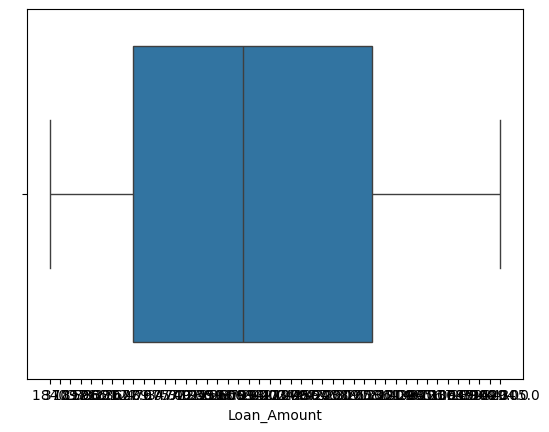

In [ ]:
sns.boxplot(x="Loan_Amount",data=data)
plt.show()

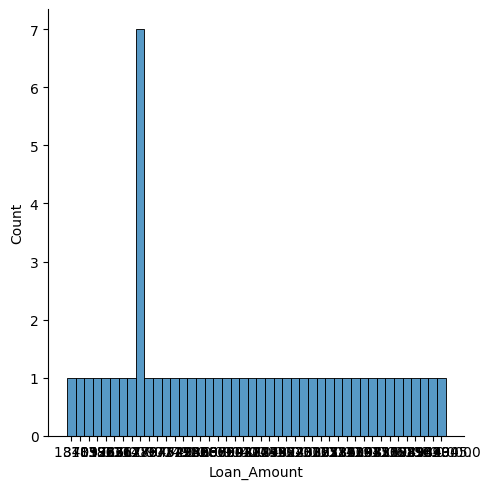

In [ ]:
sns.displot(data["Loan_Amount"])
plt.show()

In [ ]:
l = [3,4,5,6,8,4,6,7,7,8,3,100]
sum(l)/len(l)

13.416666666666666

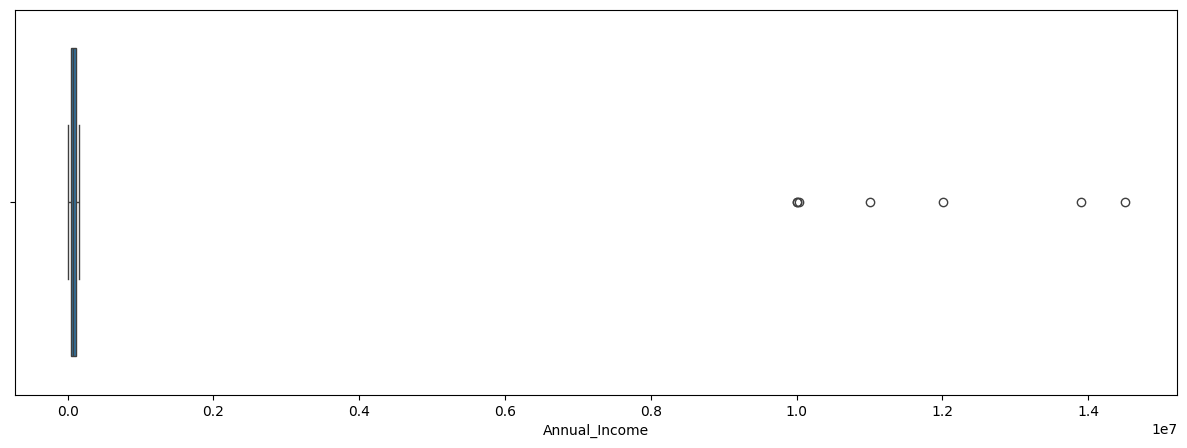

In [ ]:
plt.figure(figsize=(15,5))
sns.boxplot(x="Annual_Income",data=data)
plt.show()

In [ ]:
data.shape

(50, 20)

In [ ]:
q1 = data["Annual_Income"].quantile(0.25)
q3 =data["Annual_Income"].quantile(0.75)
q3


np.float64(118306.5)

In [ ]:
IQR =q3-q1

In [ ]:
min_range = q1 - (1.5 * IQR)
max_range = q3 + (1.5 * IQR)
min_range, max_range

(np.float64(-70881.625), np.float64(231819.375))

In [ ]:
new_dataset=data[data["Annual_Income"]<=max_range]

In [ ]:
new_dataset.shape

(43, 20)

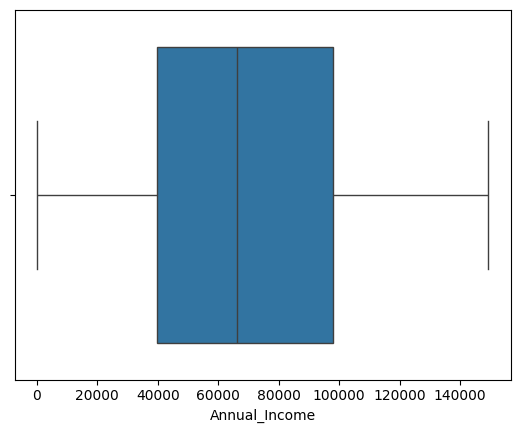

In [ ]:
sns.boxplot(x="Annual_Income",data=new_dataset)
plt.show()

In [ ]:
new_dataset.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,,1.0,High School,,146114.0,815.0,18403.0,12.0,Urban,Yes,,2025-11-24,2025-10-02,,,1404.0,
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.0,,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,,Branch
3,L1003,63.0,Female,Divorced,,Graduate,Salaried,132296.0,348.0,15966.0,,Rural,,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,,38621.0,60.0,Rural,No,,2025-05-06,,10.53,39.0,13763.0,Phone


In [ ]:
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,,1.0,High School,,146114.0,815.0,18403.0,12.0,Urban,Yes,,2025-11-24,2025-10-02,,,1404.0,
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.0,,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,,Branch
3,L1003,63.0,Female,Divorced,,Graduate,Salaried,132296.0,348.0,15966.0,,Rural,,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,,38621.0,60.0,Rural,No,,2025-05-06,,10.53,39.0,13763.0,Phone


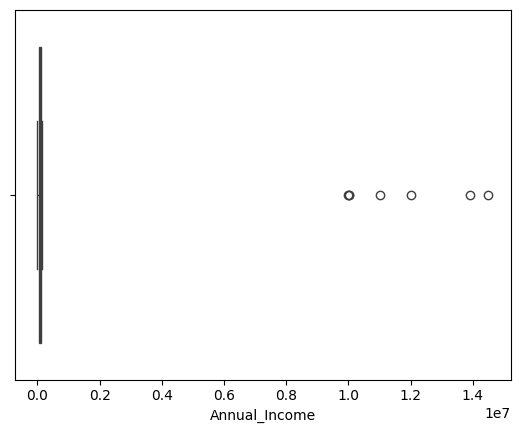

In [ ]:
sns.boxplot(x="Annual_Income",data=data)
plt.show()

In [ ]:
data.describe()

,Annual_Income
count,5.000000e+01
mean,1.687992e+06
std,4.109913e+06
min,2.000000e+02
25%,4.263125e+04
50%,6.974250e+04
75%,1.183065e+05
max,1.450062e+07


<Axes: xlabel='Annual_Income'>

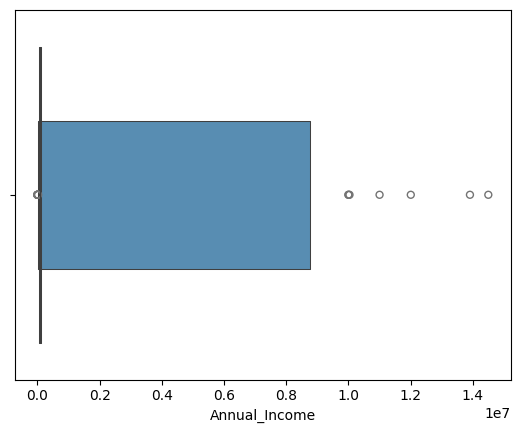

In [ ]:
sns.boxenplot(x="Annual_Income",data=data)

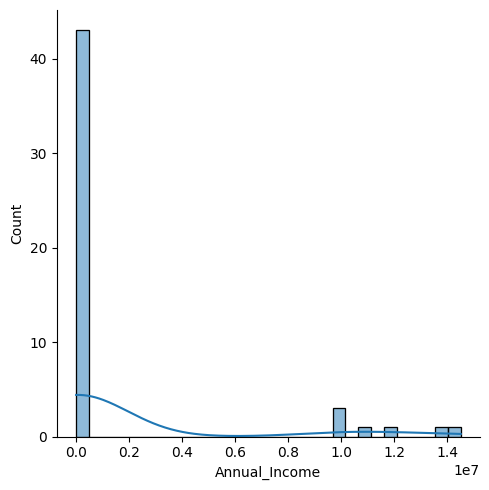

In [ ]:
sns.displot(data["Annual_Income"], kde=True, bins=30)
plt.show()


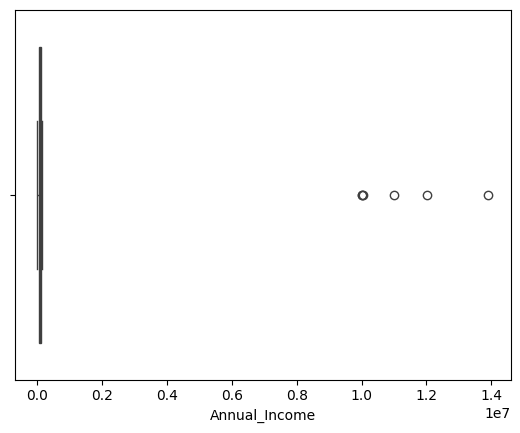

In [44]:
min_range = data["Annual_Income"].mean() - (3 * data["Annual_Income"].std())
max_range = data["Annual_Income"].mean() + (3 * data["Annual_Income"].std())

new_annual_data = data[(data["Annual_Income"] >= min_range) & (data["Annual_Income"] <= max_range)]
sns.boxplot(x="Annual_Income", data=new_annual_data)
plt.show()


In [45]:
new_annual_data.shape

(49, 21)

In [34]:
z_score = (data["Annual_Income"] - data["Annual_Income"].mean())/(data["Annual_Income"].std())


In [41]:
data["Z_score"] = z_score

In [43]:
data[data["Z_score"]<3]

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,...,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method,Z_score
0,L1000,59.0,Male,,1.0,High School,,146114.0,815.0,18403.0,...,Urban,Yes,,2025-11-24,2025-10-02,,,1404.0,,-0.375161
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,...,Urban,No,Approved,2025-02-27,2025-03-05,11.0,,41943.0,Branch,-0.390971
2,L1002,35.0,Male,Single,3.0,High School,,70108.0,491.0,18121.0,...,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,,Branch,-0.393654
3,L1003,63.0,Female,Divorced,,Graduate,Salaried,132296.0,348.0,15966.0,...,Rural,,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch,-0.378523
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,,38621.0,...,Rural,No,,2025-05-06,,10.53,39.0,13763.0,Phone,-0.382931
5,L1005,41.0,Female,Single,0.0,Postgraduate,Unemployed,500.0,316.0,33312.0,...,Urban,No,Rejected,,2025-05-31,7.51,39.0,19384.0,Phone,-0.410591
6,L1006,59.0,Male,,,Graduate,Self-employed,9999999.0,471.0,27677.0,...,Rural,Yes,Approved,2025-03-13,2025-11-18,,48.0,33606.0,Phone,2.022429
7,L1007,39.0,Male,Divorced,4.0,Postgraduate,Salaried,43328.0,519.0,36289.0,...,Urban,No,Approved,2025-02-22,2025-11-13,10.72,,10860.0,,-0.400170
8,L1008,43.0,Female,Single,3.0,,,13910081.0,457.0,,...,,Yes,Approved,2025-12-13,2025-07-05,8.97,47.0,39757.0,Phone,2.973807
9,L1009,31.0,Male,Single,4.0,High School,Salaried,111412.0,,47675.0,...,Semiurban,Yes,Approved,2025-10-07,2025-10-23,7.89,38.0,16106.0,,-0.383604
